In [3]:
import pandas as pd
from prophet import Prophet

df=pd.read_csv('Shop Direct Sale Data For Research.csv')

df.head(5)

c:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Order ID,Order Date,Customer Name,City,Country,State,Region,Segment,Category,Ship Mode,Sub-Category,Product Name,Quantity,Cost,Profit,Sales,Year
0,1,2017-01-01,Ruby Patel,Stockholm,Sweden,Stockholm,North,Home Office,Office Supplies,Economy Plus,Paper,"Enermax Note Cards, Premium",3,9,36,45,2017
1,2,2017-01-03,Summer Hayward,Southport,United Kingdom,England,North,Consumer,Furniture,Economy,Bookcases,"Dania Corner Shelving, Traditional",7,255,599,854,2017
2,3,2017-01-04,Devin Huddleston,Valence,France,Auvergne-Rhône-Alpes,Central,Consumer,Office Supplies,Economy,Art,"Binney & Smith Sketch Pad, Easy-Erase",3,48,92,140,2017
3,4,2017-01-04,Mary Parker,Birmingham,United Kingdom,England,North,Corporate,Office Supplies,Economy,Art,"Boston Markers, Easy-Erase",2,9,18,27,2017
4,5,2017-01-05,Daniel Burke,Echirolles,France,Auvergne-Rhône-Alpes,Central,Home Office,Office Supplies,Priority,Art,"Binney & Smith Pencil Sharpener, Water Color",3,40,50,90,2017


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4115 entries, 0 to 4114
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order ID       4115 non-null   int64 
 1   Order Date     4115 non-null   object
 2   Customer Name  4115 non-null   object
 3   City           4115 non-null   object
 4   Country        4115 non-null   object
 5   State          4115 non-null   object
 6   Region         4115 non-null   object
 7   Segment        4115 non-null   object
 8   Category       4115 non-null   object
 9   Ship Mode      4115 non-null   object
 10  Sub-Category   4115 non-null   object
 11  Product Name   4115 non-null   object
 12  Quantity       4115 non-null   int64 
 13  Cost           4115 non-null   int64 
 14  Profit         4115 non-null   int64 
 15  Sales          4115 non-null   int64 
 16  Year           4115 non-null   int64 
dtypes: int64(6), object(11)
memory usage: 546.7+ KB


In [ ]:
# Oylar bo'yicha savdolarni guruhlash
df['Order Date'] = pd.to_datetime(df['Order Date'])
df_prophet = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()

# Ustun nomlarini reanme qilish
df_prophet = df_prophet.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

# Modelni 
model = Prophet()
model.fit(df_prophet)

# Kelgusi 6 oy uchun 
future = model.make_future_dataframe(periods=6, freq='ME')
forecast = model.predict(future)

# Bashorat natijalarining oxirgi 6 oyi
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6)



10:26:10 - cmdstanpy - INFO - Chain [1] start processing
10:26:11 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
48,2021-01-31,31336.852493,25908.446105,36881.011379
49,2021-02-28,29783.825253,24431.904683,35429.488214
50,2021-03-31,29681.347396,23980.092521,35236.421759
51,2021-04-30,31011.852436,25826.068516,36202.822143
52,2021-05-31,30326.965390,25077.922836,35423.164560
53,2021-06-30,48752.400259,43233.988621,54049.927852


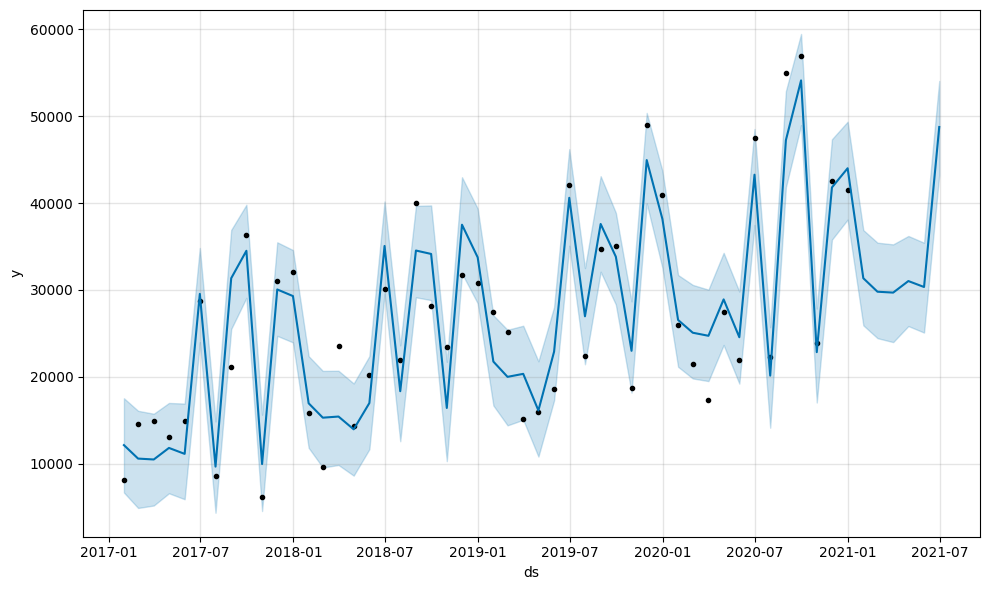

In [14]:
fig1=model.plot(forecast)